In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Telso_churm_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# replace no value with 0 and change its datatype

In [4]:
df['TotalCharges'] = df['TotalCharges'].replace(' ','0')
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["customerID"].duplicated().sum()

np.int64(0)

In [10]:
#Convert 0 and 1 into yes or no for better understanding 
def Conv(value):
    if value == 1:
        return 'yes'
    else :
        return 'no'
# convert in the SeniorCitizen
df["SeniorCitizen"] = df["SeniorCitizen"].apply(Conv)

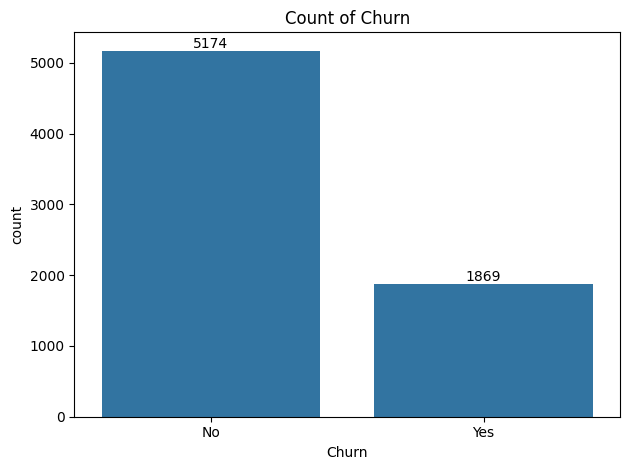

In [11]:
plt.title("Count of Churn")
ax = sns.countplot(x='Churn',data=df)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.savefig("Count of churn")
plt.show()

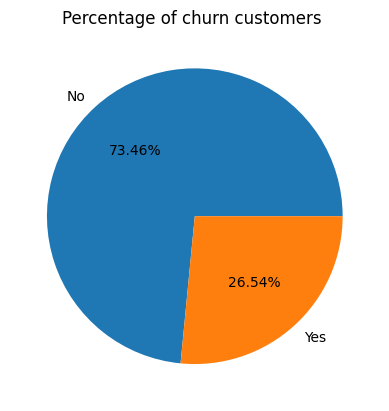

In [12]:
# bar plot of this 
gb = df.groupby('Churn').agg({'Churn':'count'})
plt.title("Percentage of churn customers ")
plt.pie(gb['Churn'],labels=gb.index,autopct="%1.2f%%")
plt.savefig("Percentage of churn customers")
plt.show()

"From the given pie graph we can say that the 26.54% have churmed out."
'"The reason is bcz more company like jio are in market and the price is lower than it "'

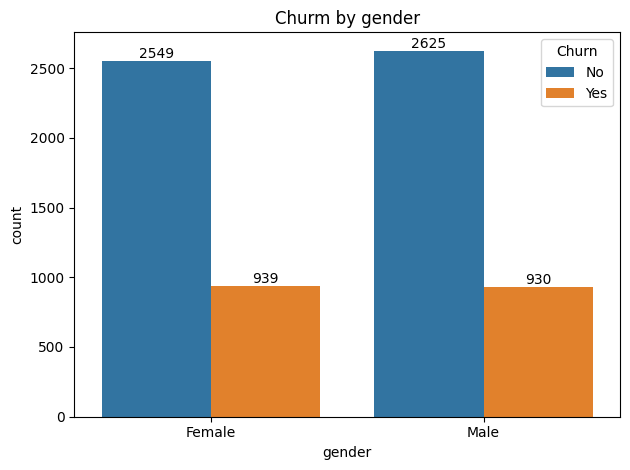

In [13]:
plt.title("Churm by gender")
ax = sns.countplot(x='gender',data=df,hue='Churn')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig("Churm by gender")
plt.show()

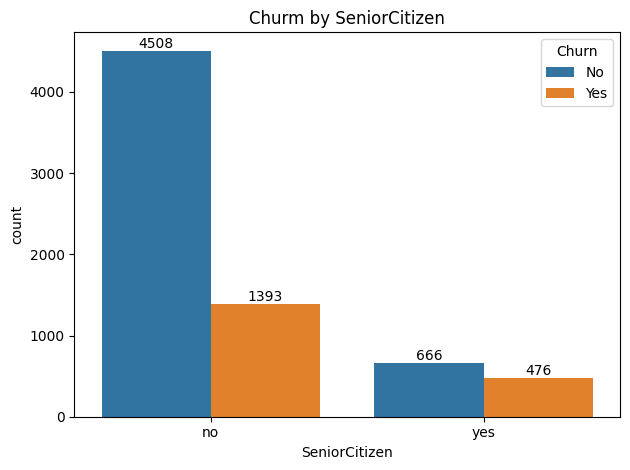

In [14]:
plt.title("Churm by SeniorCitizen")
ax = sns.countplot(x='SeniorCitizen',data=df,hue='Churn')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

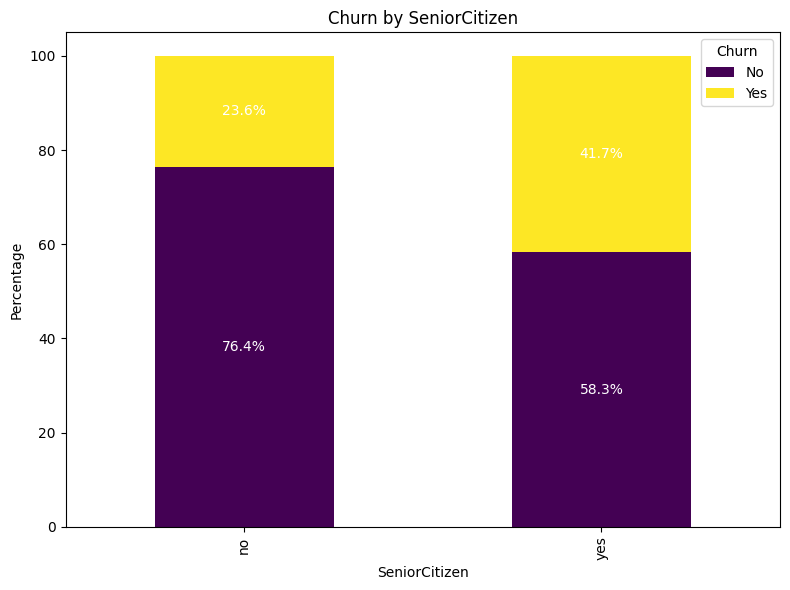

In [15]:
# Assuming df is already defined and has 'SeniorCitizen' and 'Churn' columns
# Step 1: Create a crosstab of counts
crosstab = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Step 2: Convert to percentages
crosstab_percent = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

# Step 3: Plot the stacked bar chart
ax = crosstab_percent.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 6))

# Step 4: Add percentage labels
for i, (index, row) in enumerate(crosstab_percent.iterrows()):
    cumulative = 0
    for j, value in enumerate(row):
        if value > 0:
            ax.text(i, cumulative + value / 2, f"{value:.1f}%", ha='center', va='center', color='white', fontsize=10)
            cumulative += value

# Final touch
plt.title("Churn by SeniorCitizen")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.legend(title='Churn')
plt.tight_layout()
plt.savefig("Churm by SenirCitizen")
plt.show()

"From this chart we can say that the more seniorCitizen have churmed out"

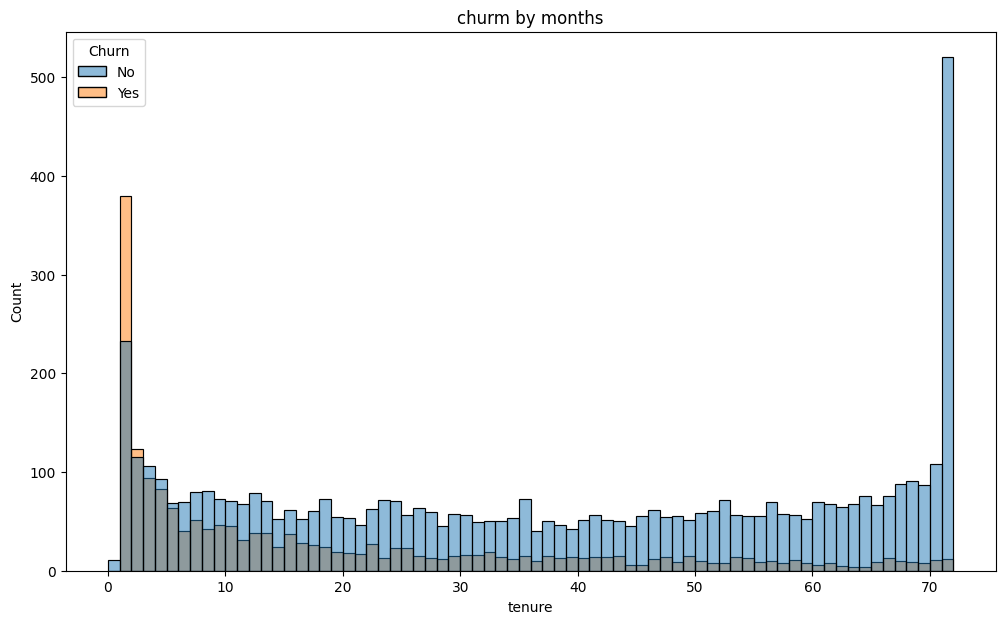

In [16]:
plt.figure(figsize=(12,7))
sns.histplot(x='tenure',data=df,bins=72,hue='Churn')
plt.title("churm by months")
plt.savefig("Churm by months")
plt.show()

"People who have used our services for a long time are stayed and people who have used are services less time is Churm"

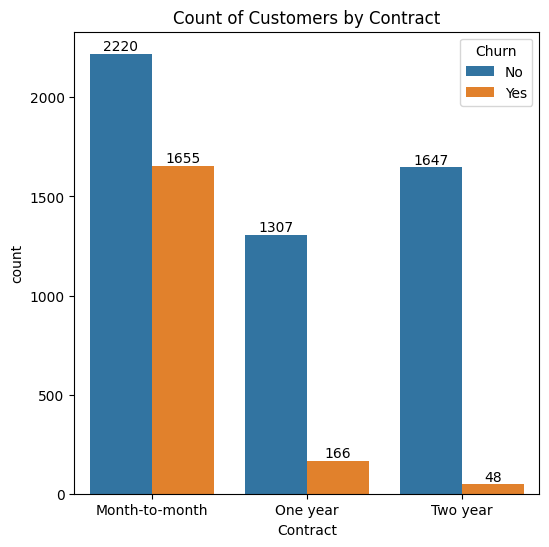

In [17]:
plt.figure(figsize=(6,6))
ax = sns.countplot(x="Contract",data=df,hue='Churn')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Count of Customers by Contract")
plt.show()

""That people who have months-to-months contract are likely to churn from those who have 1 or 2 years of contract""

In [18]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

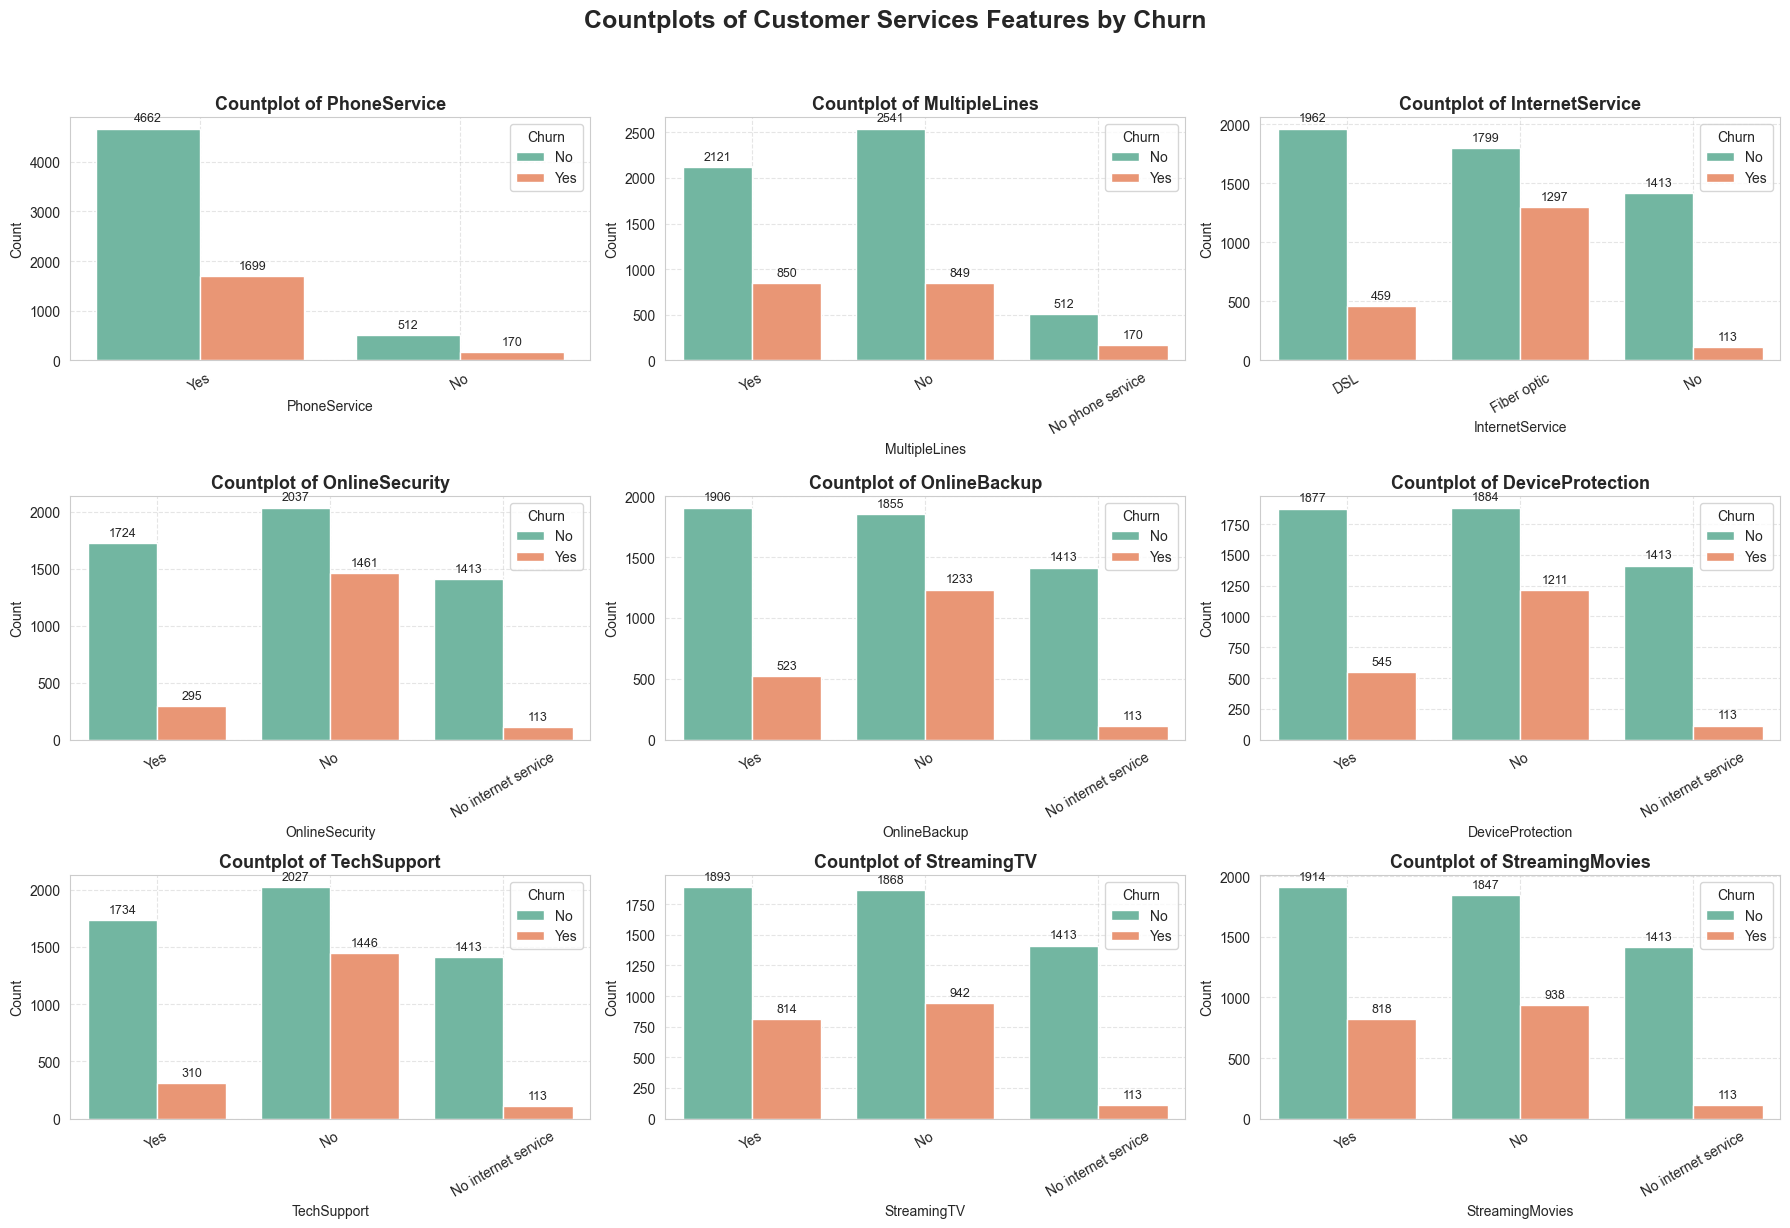

In [19]:
# Assume df is your DataFrame and 'Churn' column exists
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Layout settings
n_cols = 3
n_rows = -(-len(columns) // n_cols)

sns.set_style("whitegrid")
palette = sns.color_palette("Set2")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(columns):
    unique_vals = df[col].unique().tolist()

    # Define category order per column type
    if col == 'InternetService':
        order = ['DSL', 'Fiber optic', 'No']
    elif 'phone' in col.lower():
        order = ['Yes', 'No']
    elif 'Service' in col or 'Lines' in col:
        order = ['Yes', 'No', 'No phone service']
    elif 'Online' in col or 'Streaming' in col or 'Support' in col or 'Protection' in col:
        order = ['Yes', 'No', 'No internet service']
    else:
        order = unique_vals

    order = [val for val in order if val in unique_vals]

    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], order=order, palette='Set2')
    axes[i].set_title(f"Countplot of {col}", fontsize=13, fontweight='bold')
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # Add annotations (counts on bars)
    for container in axes[i].containers:
        for bar in container:
            height = bar.get_height()
            if height > 0:
                axes[i].annotate(f'{int(height)}',
                                 xy=(bar.get_x() + bar.get_width() / 2, height),
                                 xytext=(0, 3), textcoords='offset points',
                                 ha='center', va='bottom', fontsize=9)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Main title
fig.suptitle("Countplots of Customer Services Features by Churn", fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("Countplots of Customer Services Features by Churn")
plt.show()


 "This set of countplots compares various customer service features against churn behavior. It reveals that customers lacking services like OnlineSecurity, TechSupport, or DeviceProtection are more likely to churn. Additionally, fiber optic internet users show a notably higher churn rate than DSL users. Overall, the presence of support and protection services correlates with lower churn rates."

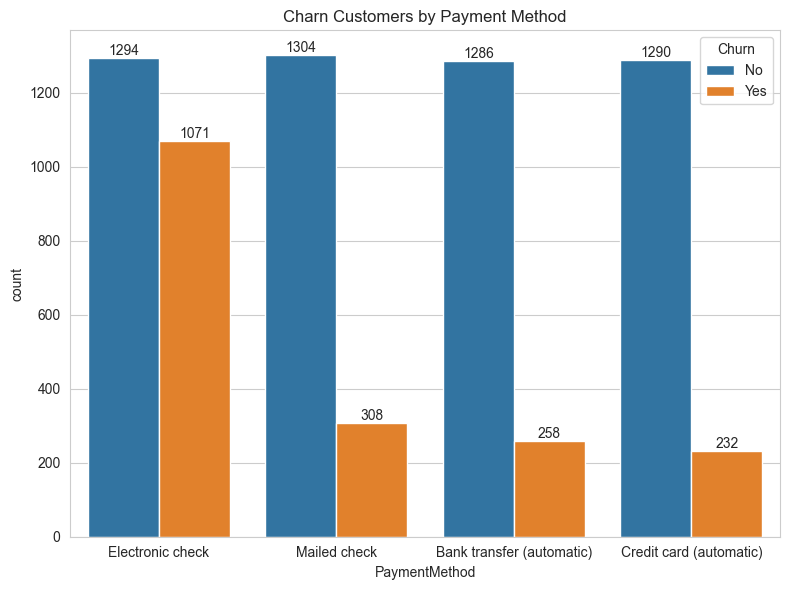

In [20]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x="PaymentMethod",data=df,hue='Churn')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Charn Customers by Payment Method")
plt.tight_layout()
plt.show()

"Customers is likely to charn he is useing the electric check as payment methods"